# Labwork 5 -- Gaussian Blur Convolution
Le Nghiem Thanh Thuy - 2540023

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import cuda
from skimage import data

print("CUDA available:", cuda.is_available())

CUDA available: True


In [2]:
kernel = np.array([
    [0, 0, 1, 2, 1, 0, 0],
    [0, 3, 13, 22, 13, 3, 0],
    [1, 13, 59, 97, 59, 13, 1],
    [2, 22, 97, 159, 97, 22, 2],
    [1, 13, 59, 97, 59, 13, 1],
    [0, 3, 13, 22, 13, 3, 0],
    [0, 0, 1, 2, 1, 0, 0]
])

img = data.astronaut()

#kernel = kernel / kernel.sum()

In [5]:
 kernel.sum()

np.int64(1003)

## 1. CPU Version

In [3]:
def convolutionCpu(image, kernel):
    h, w, c = image.shape
    p = kernel.shape[0] // 2
    image = np.pad(image, ((p,p), (p,p), (0,0)))
    out = np.zeros((h, w, c))

    for i in range(h):
        for j in range(w):
            for k in range(c):
                out[i,j,k] = np.sum(image[i:i+7, j:j+7, k] * kernel) // 1003

    return np.clip(out, 0, 255).astype(np.uint8)

In [4]:
start = time.time()
blur_cpu_img = convolutionCpu(img, kernel)
cpuTime = time.time() - start
print(f"CPU time: {cpuTime * 1000:.2f} ms")

CPU time: 8970.98 ms


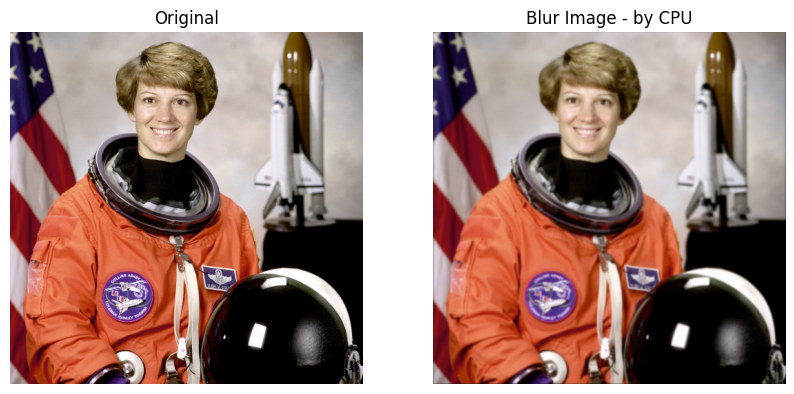

In [6]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Blur Image - by CPU")
plt.imshow(blur_cpu_img)
plt.axis("off")

plt.show()

## 2. Not Shared memory GPU version

In [7]:
@cuda.jit
def convolutionGpu(src, dst, kernel, kernelSum):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x  # column
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y  # row

    height = src.shape[0]
    width = src.shape[1]
    if tidx >= width or tidy >= height:
        return

    p = kernel.shape[0] // 2  # 3 for a 7x7 kernel

    # no numpy inside a cuda kernel: the window has to be summed with plain loops
    for c in range(src.shape[2]):
        total = 0
        for dy in range(kernel.shape[0]):
            for dx in range(kernel.shape[1]):
                y = tidy + dy - p
                x = tidx + dx - p
                if 0 <= y < height and 0 <= x < width:  # outside the image counts as 0,
                    total += src[y, x, c] * kernel[dy, dx]  # like the padding on the CPU

        g = total // kernelSum
        if g < 0:
            g = 0
        elif g > 255:
            g = 255
        dst[tidy, tidx, c] = g

## 3. Check that both give the same image

In [8]:
height, width, channels = img.shape
kernelSum = int(kernel.sum())

devSrc = cuda.to_device(img)
devKernel = cuda.to_device(kernel)
devDst = cuda.device_array((height, width, channels), np.uint8)

blockSize2D = (16, 16)
gridSize2D = ((width + blockSize2D[0] - 1) // blockSize2D[0],
              (height + blockSize2D[1] - 1) // blockSize2D[1])

start = time.time()
convolutionGpu[gridSize2D, blockSize2D](devSrc, devDst, devKernel, kernelSum)
cuda.synchronize()
gpuTime = time.time() - start

blur_gpu_img = devDst.copy_to_host()

print(f"GPU time: {gpuTime * 1000:.2f} ms")
print("CPU and GPU give the same image:", np.array_equal(blur_gpu_img, blur_cpu_img))

GPU time: 2420.58 ms
CPU and GPU give the same image: True


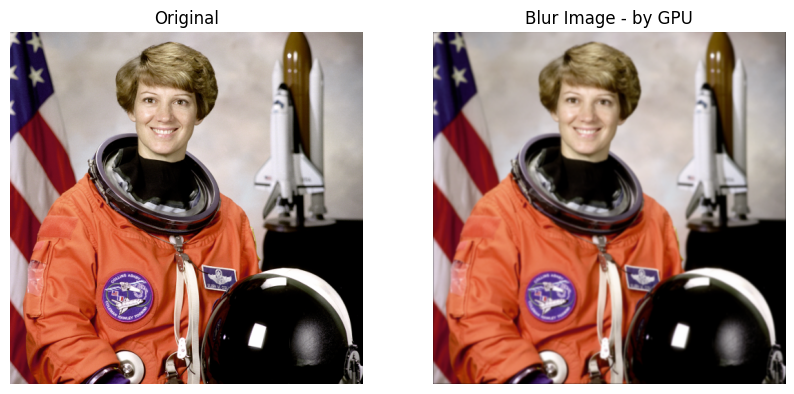

In [9]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Blur Image - by GPU")
plt.imshow(blur_gpu_img)
plt.axis("off")
plt.show()

## 4. Shared memory GPU Version
Neighbouring threads convolve overlapping $7\times7$ windows, so without shared memory the
same source pixel is read from global memory up to 49 times. Here each block first copies
the part of the image it needs into shared memory, and then every thread reads its window
from there.

The tile is bigger than the block, because the threads on the edge still need 3 pixels
around them (the halo): a $(b_x, b_y)$ block needs a $(b_x + 6, b_y + 6)$ tile. A shared
array must have a size known at compile time, so I declare the largest one I use,
$38\times38$, which supports blocks up to $32\times32$.

Loading the tile takes more threads than the block has, so each thread loads several
pixels in a strided loop. `cuda.syncthreads()` after the loading makes every thread wait
until the whole tile is ready.

In [10]:
P = 3                  # kernel radius, 7 // 2
TILE = 32 + 2 * P      # biggest tile supported: blocks up to 32x32


@cuda.jit
def convolutionShared(src, dst, kernel, kernelSum):
    height = src.shape[0]
    width = src.shape[1]
    channels = src.shape[2]

    tile = cuda.shared.array((TILE, TILE, 3), numba.uint8)

    blockStartX = cuda.blockIdx.x * cuda.blockDim.x
    blockStartY = cuda.blockIdx.y * cuda.blockDim.y
    tileW = cuda.blockDim.x + 2 * P
    tileH = cuda.blockDim.y + 2 * P

    # load the tile with its halo; the tile is bigger than the block, so each
    # thread loads several pixels
    ty = cuda.threadIdx.y
    while ty < tileH:
        tx = cuda.threadIdx.x
        while tx < tileW:
            y = blockStartY + ty - P
            x = blockStartX + tx - P
            for c in range(channels):
                if 0 <= y < height and 0 <= x < width:
                    tile[ty, tx, c] = src[y, x, c]
                else:
                    tile[ty, tx, c] = 0       # outside the image counts as 0
            tx += cuda.blockDim.x
        ty += cuda.blockDim.y

    cuda.syncthreads()   # every thread must reach this, so it comes before any return

    tidx = blockStartX + cuda.threadIdx.x
    tidy = blockStartY + cuda.threadIdx.y
    if tidx >= width or tidy >= height:
        return

    for c in range(channels):
        total = 0
        for dy in range(kernel.shape[0]):
            for dx in range(kernel.shape[1]):
                total += tile[cuda.threadIdx.y + dy, cuda.threadIdx.x + dx, c] * kernel[dy, dx]

        g = total // kernelSum
        if g < 0:
            g = 0
        elif g > 255:
            g = 255
        dst[tidy, tidx, c] = g

In [11]:
devDstShared = cuda.device_array((height, width, channels), np.uint8)

start = time.time()
convolutionShared[gridSize2D, blockSize2D](devSrc, devDstShared, devKernel, kernelSum)
cuda.synchronize()
sharedTime = time.time() - start

blur_shared_img = devDstShared.copy_to_host()

print(f"GPU shared memory time: {sharedTime * 1000:.2f} ms")
print("same as the version without shared memory:",
      np.array_equal(blur_shared_img, blur_gpu_img))
print("same as the CPU version:",
      np.array_equal(blur_shared_img, blur_cpu_img))

GPU shared memory time: 517.00 ms
same as the version without shared memory: True
same as the CPU version: True


## 5. Different block sizes


In [12]:
lsBlockSizes = [(8, 8), (16, 8), (16, 16), (32, 8), (16, 32), (32, 32)]
nRuns = 20

def bench(kernel, gridSize, blockSize, devDst):
    kernel[gridSize, blockSize](devSrc, devDst, devKernel, kernelSum)  # warm-up
    cuda.synchronize()

    best = float("inf")
    for _ in range(nRuns):
        start = time.time()
        kernel[gridSize, blockSize](devSrc, devDst, devKernel, kernelSum)
        cuda.synchronize()
        best = min(best, time.time() - start)
    return best * 1000   # ms


# keep the GPU busy for a second so the clock is already boosted
warmStart = time.time()
while time.time() - warmStart < 1.0:
    convolutionGpu[gridSize2D, blockSize2D](devSrc, devDst, devKernel, kernelSum)
cuda.synchronize()

lsTimesPlain = []
lsTimesShared = []
for blockSize in lsBlockSizes:
    gridSize = ((width + blockSize[0] - 1) // blockSize[0],
                (height + blockSize[1] - 1) // blockSize[1])

    tPlain = bench(convolutionGpu, gridSize, blockSize, devDst)
    tShared = bench(convolutionShared, gridSize, blockSize, devDstShared)

    lsTimesPlain.append(tPlain)
    lsTimesShared.append(tShared)
    print(f"block {str(blockSize):9s} grid {str(gridSize):10s}  "
          f"global {tPlain:7.3f} ms   shared {tShared:7.3f} ms   "
          f"-> {tPlain / tShared:.2f}x")

block (8, 8)    grid (64, 64)    global   0.521 ms   shared   0.386 ms   -> 1.35x
block (16, 8)   grid (32, 64)    global   0.512 ms   shared   0.379 ms   -> 1.35x
block (16, 16)  grid (32, 32)    global   0.510 ms   shared   0.374 ms   -> 1.36x
block (32, 8)   grid (16, 64)    global   0.510 ms   shared   0.380 ms   -> 1.34x
block (16, 32)  grid (32, 16)    global   0.504 ms   shared   0.367 ms   -> 1.37x
block (32, 32)  grid (16, 16)    global   0.540 ms   shared   0.395 ms   -> 1.37x


## 6. Comparison

In [13]:
bestPlain = min(zip(lsTimesPlain, lsBlockSizes), key=lambda p: p[0])
bestShared = min(zip(lsTimesShared, lsBlockSizes), key=lambda p: p[0])

print(f"CPU                  : {cpuTime * 1000:9.2f} ms")
print(f"GPU global memory    : {bestPlain[0]:9.3f} ms   (block {bestPlain[1]})")
print(f"GPU shared memory    : {bestShared[0]:9.3f} ms   (block {bestShared[1]})")
print()
print(f"shared vs global : {bestPlain[0] / bestShared[0]:.2f}x")
print(f"shared vs CPU    : {cpuTime * 1000 / bestShared[0]:.0f}x")

CPU                  :   8970.98 ms
GPU global memory    :     0.504 ms   (block (16, 32))
GPU shared memory    :     0.367 ms   (block (16, 32))

shared vs global : 1.37x
shared vs CPU    : 24417x


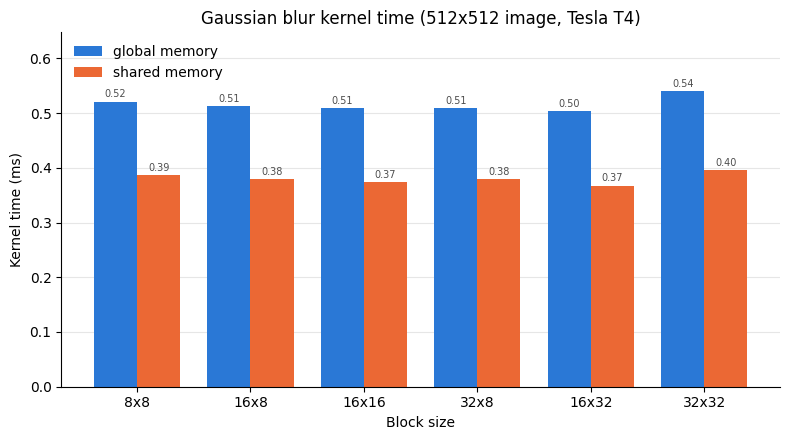

In [14]:
labels = [f"{b[0]}x{b[1]}" for b in lsBlockSizes]
x = np.arange(len(labels))
barWidth = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))
bars1 = ax.bar(x - barWidth / 2, lsTimesPlain, barWidth,
               color="#2a78d6", label="global memory")
bars2 = ax.bar(x + barWidth / 2, lsTimesShared, barWidth,
               color="#eb6834", label="shared memory")

ax.set_title("Gaussian blur kernel time (512x512 image, Tesla T4)")
ax.set_xlabel("Block size")
ax.set_ylabel("Kernel time (ms)")
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0, max(lsTimesPlain + lsTimesShared) * 1.20)
ax.grid(axis="y", color="0.9")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

for bars in (bars1, bars2):
    for bar in bars:
        ax.annotate(f"{bar.get_height():.2f}",
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 3),
                    ha="center", fontsize=7, color="0.3")

plt.tight_layout()
plt.savefig("blocksize_shared.png", dpi=150)
plt.show()